# Stuttering Detection: Probabilistic Analysis
---

In [1]:
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import PredefinedSplit, GridSearchCV
from sklearn.metrics import confusion_matrix
from src.data import DataManager
from src.models import NaiveBayesModel, LDAModel

## Step 2: Global Constants

In [2]:
RANDOM_SEED = 42
SAMPLE_LIMIT = None
STRICT_LABELS = True # Set to True to filter out ambiguous samples (Score 1 & 2)
CSV_PATHS = [
    "Stuttering Events in Podcasts Dataset/SEP-28k_labels.csv",
    "Stuttering Events in Podcasts Dataset/fluencybank_labels.csv"
]
FEATURE_DIR = "data/features"
fluent_dir = os.path.join(FEATURE_DIR, "fluent")
disfluent_dir = os.path.join(FEATURE_DIR, "disfluent")

## Step 3: Standardized Data Loading

In [3]:
label_dict = DataManager.generate_label_dict(CSV_PATHS, filter_quality=True, strict=STRICT_LABELS)
manager = DataManager(None, None)

# Smart Load: 50/50 split at the source
X, y = manager.load_from_folders(fluent_dir, disfluent_dir, limit=SAMPLE_LIMIT, label_dict=label_dict)

print(f"Data Loaded: {len(X)} samples.")
unique, counts = np.unique(y, return_counts=True)
for val, count in zip(unique, counts):
    label = "Fluent (0)" if val == 0 else "Disfluent (1)"
    print(f"{label}: {count} ({count/len(y)*100:.1f}%)")

[DataManager] Quality Filter: Removed 3938 low-quality samples.
[DataManager] Smart Load: Pre-selected 5000 fluent and 5000 disfluent files.
Data Loaded: 10000 samples.
Fluent (0): 5000 (50.0%)
Disfluent (1): 5000 (50.0%)


## Step 4: Data Splitting & Scaling

In [4]:
X_train, X_val, X_test, y_train, y_val, y_test = manager.get_splits(test_size=0.15, val_size=0.15)

# Standardize scaling
X_train_final = manager.preprocess(X_train, method="standard")
X_val_final = manager.preprocess(X_val, method="standard")
X_test_final = manager.preprocess(X_test, method="standard")

print(f"Final Train shape: {X_train_final.shape}")
print(f"Final Test shape: {X_test_final.shape}")

Final Train shape: (7000, 768)
Final Test shape: (1500, 768)


## Step 5: Gaussian Naive Bayes Baseline

In [5]:
nb_baseline = NaiveBayesModel("NB_Baseline")
nb_baseline.train(X_train_final, y_train)
nb_results = nb_baseline.evaluate(X_val_final, y_val)

[Model: NB_Baseline] Initialized.
[NB_Baseline] Training on 7000 samples...

--- Evaluation: NB_Baseline ---
Accuracy: 0.6267
Precision: 0.6678
Recall: 0.5040
F1: 0.5745

Confusion Matrix (Binary):
               Predicted: Fluent(0)  Predicted: Stutter(1)
True: Fluent(0)      562             188            
True: Stutter(1)     372             378            


## Step 6: LDA (Normal Bayes) Solver & Shrinkage Tuning

In [6]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

print("--- [STARTING LDA HYPERTUNING] ---")

# 1. Combine Train + Val for PredefinedSplit
X_combined = np.vstack((X_train_final, X_val_final))
y_combined = np.hstack((y_train, y_val))
test_fold = np.hstack((
    np.full(len(X_train_final), -1),
    np.full(len(X_val_final), 0)
))
pds = PredefinedSplit(test_fold=test_fold)

# 2. LDA Grid Search
# Shrinkage only works with 'lsqr' and 'eigen'
lda_grid = [
    {'solver': ['svd']}, # No shrinkage possible
    {'solver': ['lsqr', 'eigen'], 'shrinkage': ['auto', 0.1, 0.5, 0.9]}
]

gs_lda = GridSearchCV(LinearDiscriminantAnalysis(), lda_grid, cv=pds, scoring="accuracy", n_jobs=-1, verbose=1)
gs_lda.fit(X_combined, y_combined)

print(f"Best LDA Params: {gs_lda.best_params_}")
print(f"Best Val Accuracy: {gs_lda.best_score_:.4f}")

--- [STARTING LDA HYPERTUNING] ---
Fitting 1 folds for each of 9 candidates, totalling 9 fits
Best LDA Params: {'shrinkage': 0.5, 'solver': 'lsqr'}
Best Val Accuracy: 0.7253


## Step 7: Visualizing Performance Metrics

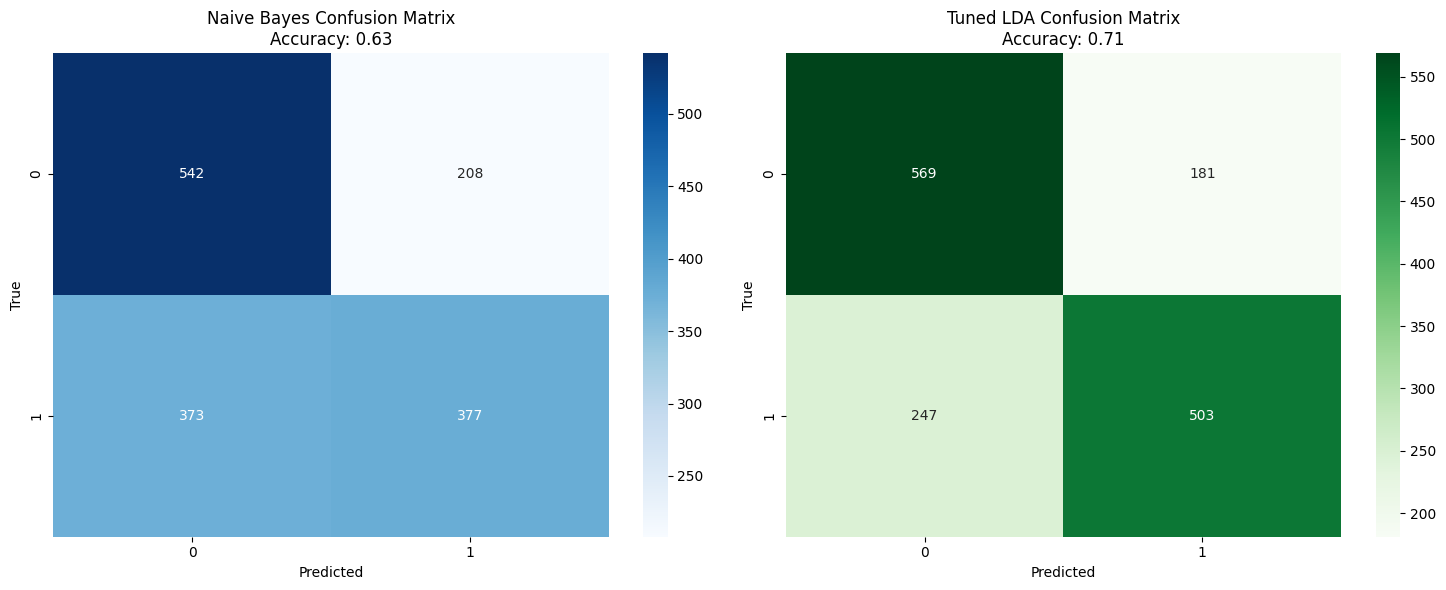

In [7]:
# Final Eval with best LDA
y_pred_lda = gs_lda.predict(X_test_final)
y_pred_nb = nb_baseline.model.predict(X_test_final)

cm_lda = confusion_matrix(y_test, y_pred_lda)
cm_nb = confusion_matrix(y_test, y_pred_nb)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Naive Bayes Confusion Matrix
Accuracy: {nb_results["accuracy"]:.2f}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(cm_lda, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title(f'Tuned LDA Confusion Matrix
Accuracy: {gs_lda.score(X_test_final, y_test):.2f}')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

## Step 8: Model Persistence

In [8]:
os.makedirs("models", exist_ok=True)
joblib.dump(gs_lda.best_estimator_, "models/probabilistic_lda_best.pkl")
print("[System] Best probabilistic model saved.")

[System] Best probabilistic model saved.
